In [ ]:
import pandas as pd
housing= pd.read_csv("https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


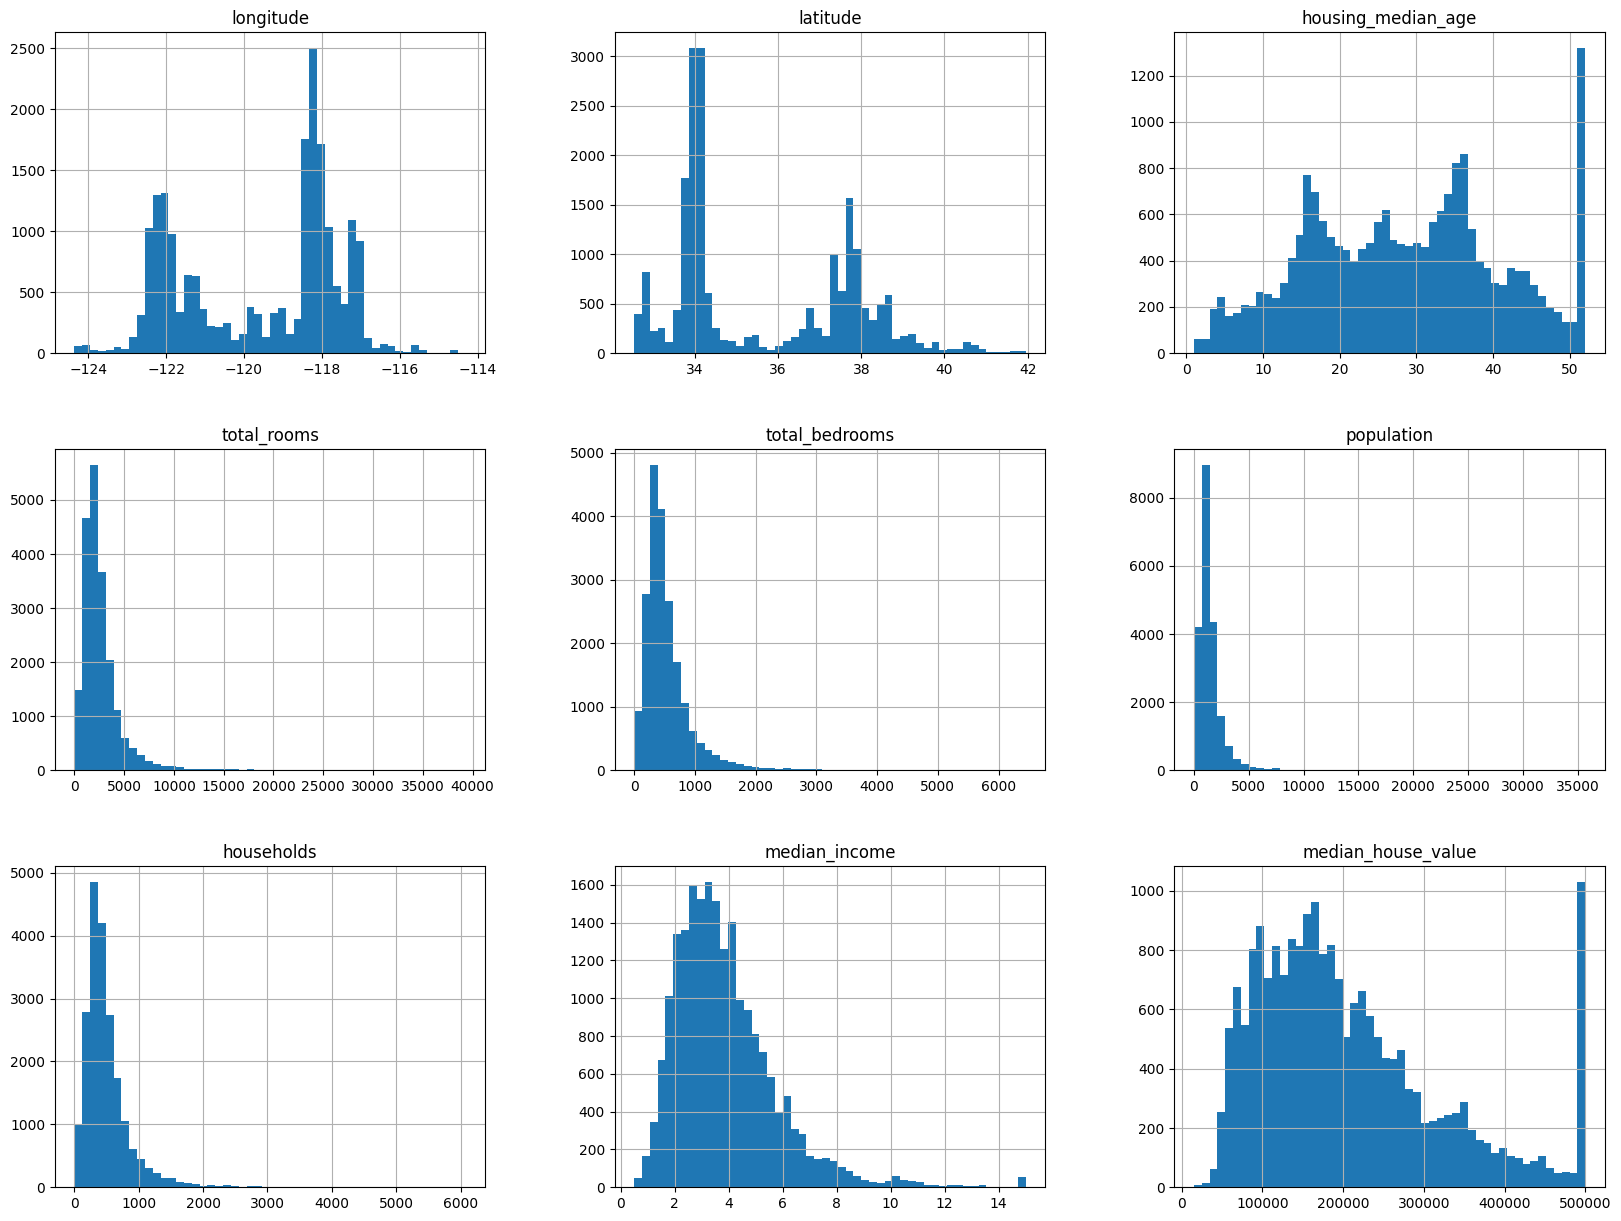

In [ ]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20, 15))
plt.show()

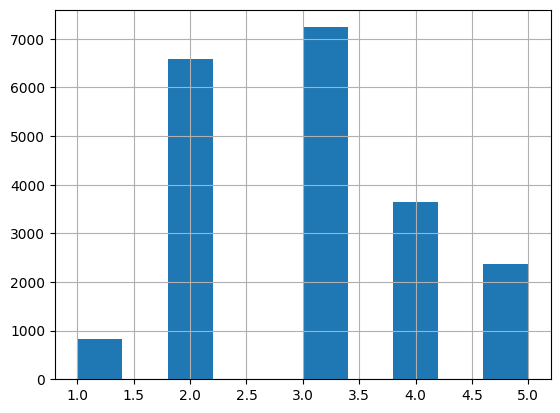

In [ ]:
import numpy as np

housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                              labels=[1, 2, 3, 4, 5])

housing["income_cat"].hist()



from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]


In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    random_state=42
)
print("Total data set: ", len(housing))
print("Training set size:", len(train_set))
print("Test set size:", len(test_set))


Total data set:  20640
Training set size: 16512
Test set size: 4128


In [ ]:
import numpy as np

housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)


In [ ]:
print(housing["income_cat"].value_counts(norm))

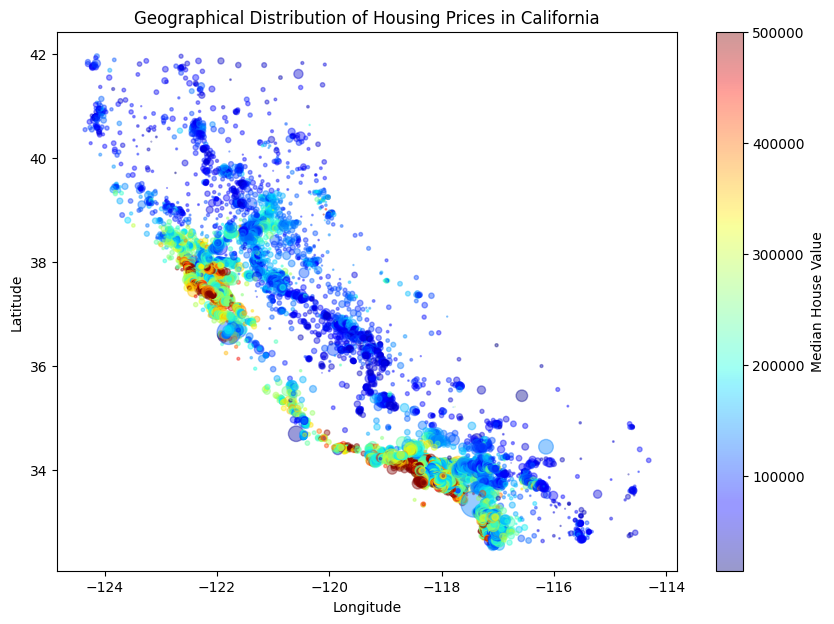

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    housing["longitude"],
    housing["latitude"],
    c=housing["median_house_value"],
    cmap="jet",
    alpha=0.4,
    s=housing["population"]/100
)

plt.colorbar(scatter, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Housing Prices in California")
plt.show()

In [ ]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)


,median_house_value
median_house_value,1.000000
median_income,0.688075
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population,-0.024650
longitude,-0.045967
latitude,-0.144160


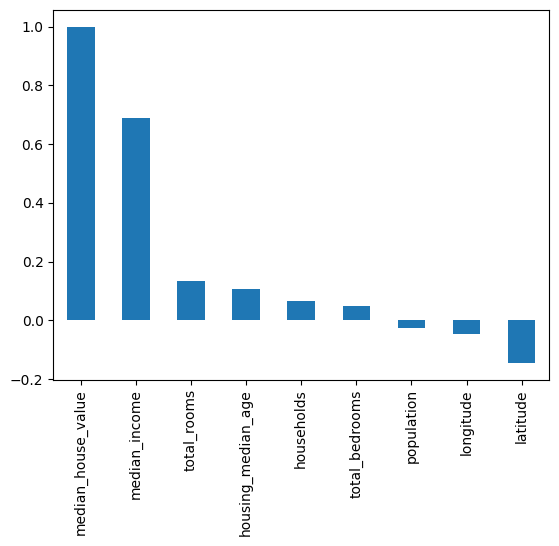

NameError: name 'median_income' is not defined

In [ ]:
corr_matrix["median_house_value"].sort_values(ascending=False).plot(kind="bar")
plt.show()



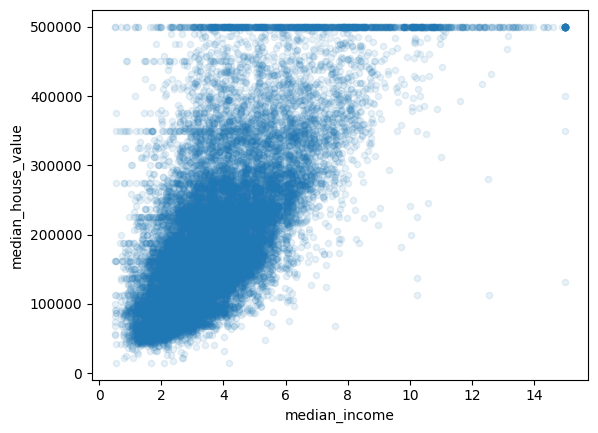

In [ ]:

housing.plot(kind="scatter",
             x="median_income",
             y="median_house_value",
             alpha=0.1)
plt.show()


In [ ]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["population_per_household"] = housing["population"] / housing["households"]


housing_numeric = housing.select_dtypes(include=["number"])

corr_matrix_new = housing_numeric.corr()
corr_with_price_new = corr_matrix_new["median_house_value"].sort_values(ascending=False)

corr_with_price_new


,median_house_value
median_house_value,1.000000
median_income,0.688075
rooms_per_household,0.151948
total_rooms,0.134153
housing_median_age,0.105623
households,0.065843
total_bedrooms,0.049686
population_per_household,-0.023737
population,-0.024650
longitude,-0.045967


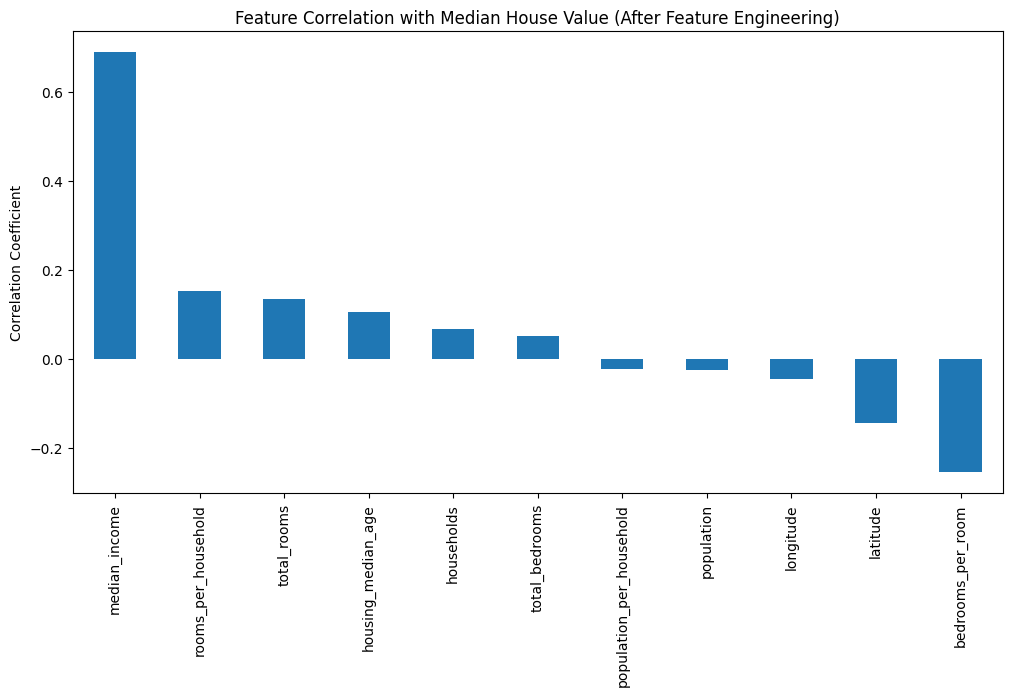

In [ ]:
import matplotlib.pyplot as plt

corr_with_price_new.drop("median_house_value").plot(
    kind="bar",
    figsize=(12,6),
    title="Feature Correlation with Median House Value (After Feature Engineering)"
)

plt.ylabel("Correlation Coefficient")
plt.show()


In [ ]:
housing_encoded = pd.get_dummies(housing, columns=["ocean_proximity"])
housing_encoded.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_cat,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,5,6.984127,0.146591,2.555556,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,5,6.238137,0.155797,2.109842,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,5,8.288136,0.129516,2.802260,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,4,5.817352,0.184458,2.547945,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3,6.281853,0.172096,2.181467,False,False,False,True,False


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rooms_per_household = X[:,3] / X[:,6]
        population_per_household = X[:,5] / X[:,6]
        return np.c_[X, rooms_per_household, population_per_household]


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("scaler", StandardScaler())
])


In [ ]:
# ---------------------------------------------
# California Housing Price Prediction Pipeline
# (Based on GeeksforGeeks reference)
# ---------------------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression

# ---------------------------------------------
# Load dataset
# ---------------------------------------------
data = pd.read_csv("https://media.geeksforgeeks.org/wp-content/uploads/20240319120216/housing.csv")

# Separate features and target
X = data.drop("median_house_value", axis=1)
y = data["median_house_value"]

# ---------------------------------------------
# Train-test split (Stratified on income)
# ---------------------------------------------
data["income_cat"] = pd.cut(
    data["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=data["income_cat"], random_state=42
)

# ---------------------------------------------
# Custom Transformer
# ---------------------------------------------
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rooms_per_household = X[:, 3] / X[:, 6]
        population_per_household = X[:, 5] / X[:, 6]

        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, 4] / X[:, 3]
            return np.c_[X, rooms_per_household, population_per_household, bedrooms_per_room]

        return np.c_[X, rooms_per_household, population_per_household]

# ---------------------------------------------
# Column identification
# ---------------------------------------------
num_features = X_train.drop("ocean_proximity", axis=1).columns
cat_features = ["ocean_proximity"]

# ---------------------------------------------
# Numerical Pipeline
# ---------------------------------------------
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("attribs_adder", CombinedAttributesAdder()),
    ("scaler", StandardScaler())
])

# ---------------------------------------------
# Categorical Pipeline
# ---------------------------------------------
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ---------------------------------------------
# Full Pipeline using ColumnTransformer
# ---------------------------------------------
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

# ---------------------------------------------
# Prepare data
# ---------------------------------------------
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

# ---------------------------------------------
# Train Model
# ---------------------------------------------
model = LinearRegression()
model.fit(X_train_prepared, y_train)

# ---------------------------------------------
# Prediction
# ---------------------------------------------
predictions = model.predict(X_test_prepared)
